# Exploratory Data Analysis (EDA)

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

In [2]:
df = pd.read_csv("retail_sales_dataset.csv")
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


## 3. Display First 5 Rows

In [3]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


## 4. Check Dataset Shape

In [4]:
df.shape

(1000, 9)

## 5. Dataset Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


## 6. Check Missing Values

In [6]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

## 7. Descriptive Statistics

In [7]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


## 8. Gender Distribution

In [8]:
df["Gender"].value_counts()

Gender
Female    510
Male      490
Name: count, dtype: int64

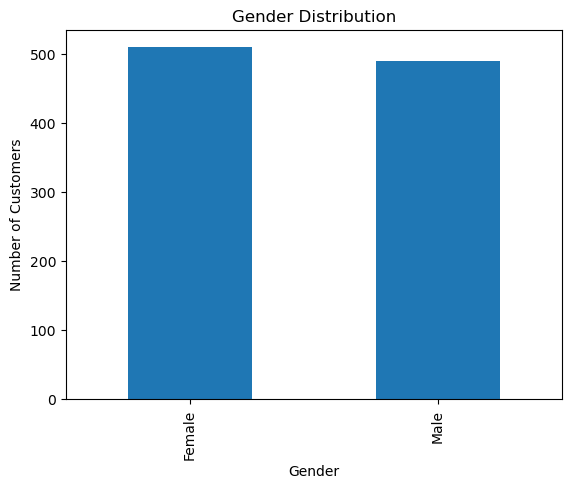

In [9]:
df["Gender"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

### Observation

- Female customers: 510
- Male customers: 490
- The customer distribution is nearly balanced.
- Female customers are slightly more than male customers.

## 9. Product Category Distribution

In [10]:
df["Product Category"].value_counts()

Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64

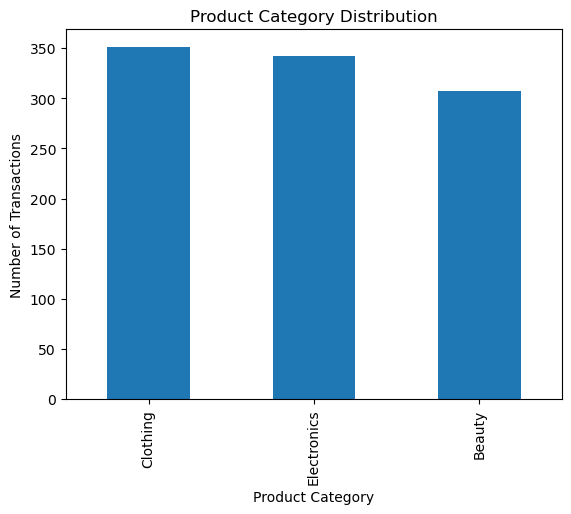

In [11]:
df["Product Category"].value_counts().plot(kind="bar")
plt.title("Product Category Distribution")
plt.xlabel("Product Category")
plt.ylabel("Number of Transactions")
plt.show()

### Observation

- Clothing has the highest number of transactions (351).
- Electronics is the second highest with 342 transactions.
- Beauty has the lowest number of transactions (307).
- Clothing products are the most popular among customers in this dataset.

## 10. Age Distribution

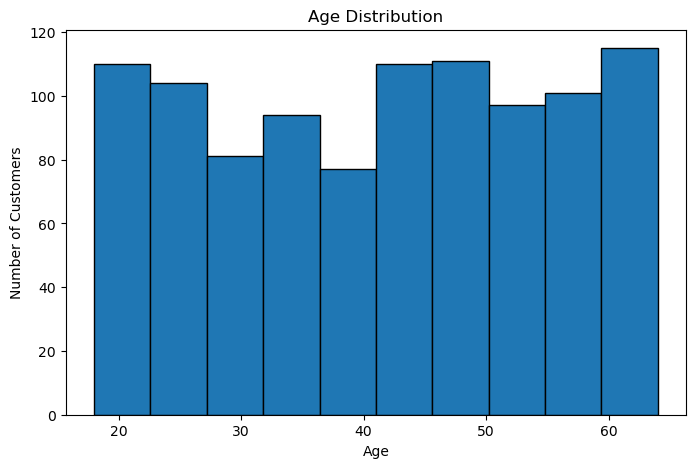

In [13]:
plt.figure(figsize=(8,5))
plt.hist(df["Age"], bins=10, edgecolor="black")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

### Observation

- Customer ages range from 18 to 64 years.
- Customers are distributed across different age groups.
- No single age group dominates the dataset.
- The retail store serves customers of various ages.

## 11. Sales by Product Category

In [14]:
category_sales = df.groupby("Product Category")["Total Amount"].sum()
category_sales

Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64

### Observation

- Electronics generated the highest total sales revenue (₹156,905).
- Clothing generated the second-highest revenue (₹155,580).
- Beauty generated the lowest revenue (₹143,515).
- Although Clothing had the highest number of transactions, Electronics generated slightly more revenue because of its higher product prices.

### Sales by Product Category Chart

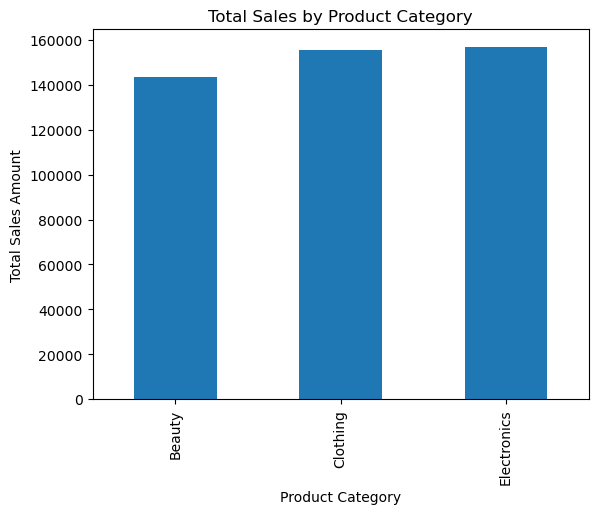

In [15]:
category_sales.plot(kind="bar")
plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales Amount")
plt.show()

## 12. Monthly Sales Trend

In [16]:
df["Date"] = pd.to_datetime(df["Date"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


### Extract Month from Date

In [17]:
df["Month"] = df["Date"].dt.month_name()
df[["Date", "Month"]].head()

,Date,Month
0,2023-11-24,November
1,2023-02-27,February
2,2023-01-13,January
3,2023-05-21,May
4,2023-05-06,May


### Monthly Sales Trend

In [18]:
monthly_sales = df.groupby("Month")["Total Amount"].sum()
monthly_sales

Month
April        33870
August       36960
December     44690
February     44060
January      36980
July         35465
June         36715
March        28990
May          53150
November     34920
October      46580
September    23620
Name: Total Amount, dtype: int64

### Observation

- May recorded the highest total sales (₹53,150).
- September recorded the lowest total sales (₹23,620).
- Sales vary across different months.
- The business can plan inventory and marketing campaigns based on monthly sales trends.

### Arrange Months in Calendar Order

In [19]:
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]
monthly_sales = monthly_sales.reindex(month_order)
monthly_sales

Month
January      36980
February     44060
March        28990
April        33870
May          53150
June         36715
July         35465
August       36960
September    23620
October      46580
November     34920
December     44690
Name: Total Amount, dtype: int64

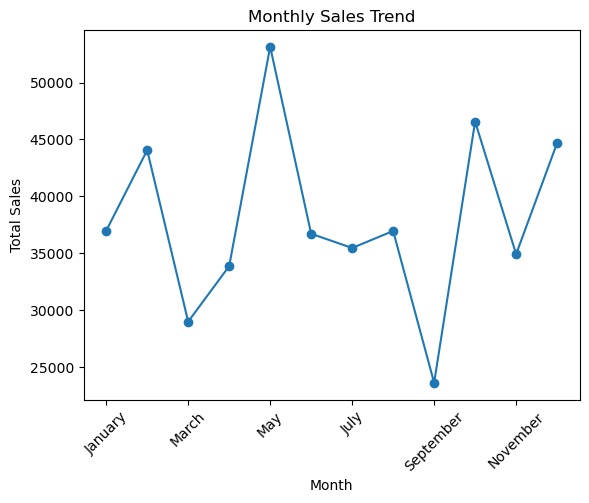

In [20]:
monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

## 13. Age vs Total Spending

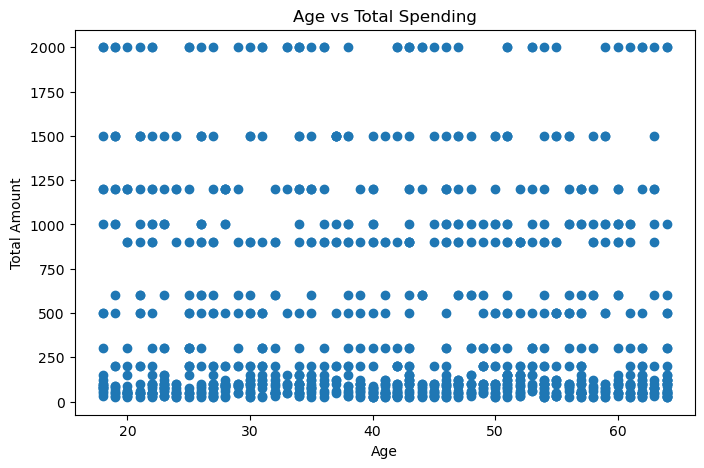

In [21]:
plt.figure(figsize=(8,5))
plt.scatter(df["Age"], df["Total Amount"])
plt.title("Age vs Total Spending")
plt.xlabel("Age")
plt.ylabel("Total Amount")
plt.show()

### Observation

- The scatter plot shows the relationship between customer age and total spending.
- The data points are widely scattered.
- There is no strong relationship between age and spending.
- Customers of different ages spend different amounts.

## 14. Correlation Matrix (Heatmap)

In [22]:
correlation = df[["Age", "Quantity", "Price per Unit", "Total Amount"]].corr()
correlation

,Age,Quantity,Price per Unit,Total Amount
Age,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.023737,1.000000,0.017501,0.373707
Price per Unit,-0.038423,0.017501,1.000000,0.851925
Total Amount,-0.060568,0.373707,0.851925,1.000000


### Observation

- Price per Unit has a strong positive correlation (0.85) with Total Amount.
- Quantity has a moderate positive correlation (0.37) with Total Amount.
- Age has almost no correlation with Total Amount.
- Product price has a greater impact on total sales than customer age.

## 15. Correlation Heatmap

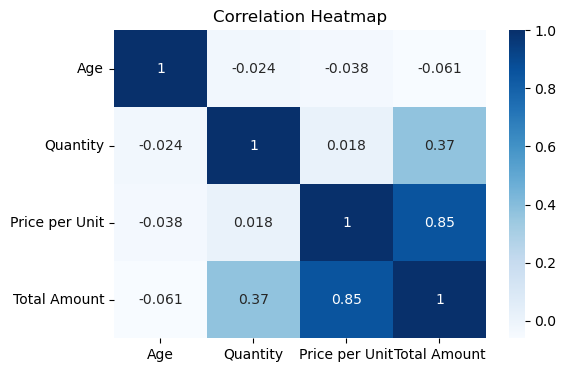

In [25]:
plt.figure(figsize=(6,4))
sns.heatmap(
    correlation,
    annot=True,
    cmap="Blues"
)
plt.title("Correlation Heatmap")
plt.show()

### Observation

- Price per Unit has the strongest positive correlation (0.85) with Total Amount.
- Quantity has a moderate positive correlation (0.37) with Total Amount.
- Age has almost no relationship with Total Amount.
- Product price influences total sales more than customer age.

# Conclusion

This Exploratory Data Analysis (EDA) was performed on the Retail Sales dataset to understand customer behavior and sales patterns.

### Key Findings

- The dataset contains 1000 customer transactions with no missing values.
- Female customers (510) are slightly more than male customers (490).
- Clothing has the highest number of transactions.
- Electronics generates the highest total sales revenue.
- Customer ages range from 18 to 64 years.
- May recorded the highest monthly sales, while September had the lowest.
- There is no strong relationship between customer age and spending.
- Price per Unit has the strongest positive correlation with Total Amount.
- Quantity has a moderate positive correlation with Total Amount.

### Business Insight

The company should focus on Electronics products because they generate the highest revenue. Additional promotions can be planned during low-sales months such as September. Pricing strategies have a greater impact on revenue than customer age.